# Лабораторна робота №3

## Візуалізація даних

У роботі використовується датасет **Adult / Census Income**.  
Мета роботи — виконати очищення даних та побудувати набір графіків для аналізу взаємозв'язків між числовими й категоріальними атрибутами.


## Завдання 1

Обрати датасет, який відповідає вимогам:

- Multivariate;
- містить categorical та integer/real атрибути;
- має щонайменше 2 числові атрибути;
- містить пропущені значення.

Для роботи обрано датасет **Adult / Census Income**.


In [1]:
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "adult.data"
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income",
]

def download_dataset() -> Path:
    """Завантажує датасет, якщо він ще не був завантажений."""
    if DATA_PATH.exists():
        print(f"Датасет уже існує: {DATA_PATH}")
        return DATA_PATH

    print("Завантаження датасету...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Датасет збережено: {DATA_PATH}")
    return DATA_PATH

download_dataset()


Завантаження датасету...
Датасет збережено: data/adult.data


PosixPath('data/adult.data')

## Завдання 2

Зчитати датасет у `pandas DataFrame` та виконати первинний огляд даних.


In [2]:
df = pd.read_csv(
    DATA_PATH,
    names=columns,
    sep=",",
    skipinitialspace=True,
    na_values="?",
)

df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.isna().sum()


,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


## Завдання 3

Виконати **Data Cleaning**:

- прибрати дублікати;
- обробити пропущені значення;
- прибрати зайві пробіли в текстових колонках;
- привести категоріальні значення до зручного вигляду.


In [5]:
def clean_adult_dataset(data: pd.DataFrame) -> pd.DataFrame:
    """Очищує датасет Adult / Census Income."""
    cleaned = data.copy()

    # Видалення дублікатів
    cleaned = cleaned.drop_duplicates()

    # Прибирання зайвих пробілів у текстових колонках
    categorical_columns = cleaned.select_dtypes(include="object").columns
    for column in categorical_columns:
        cleaned[column] = cleaned[column].astype(str).str.strip()

    # Повертаємо NaN після astype(str), якщо десь були пропуски
    cleaned = cleaned.replace("nan", np.nan)

    # Заповнення пропусків у категоріальних колонках модою
    for column in categorical_columns:
        if cleaned[column].isna().sum() > 0:
            cleaned[column] = cleaned[column].fillna(cleaned[column].mode()[0])

    # Для зручності зробимо income коротшим
    cleaned["income"] = cleaned["income"].replace({
        "<=50K": "low_income",
        ">50K": "high_income",
    })

    return cleaned.reset_index(drop=True)

clean_df = clean_adult_dataset(df)
clean_df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,low_income
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,low_income
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,low_income
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,low_income
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,low_income


In [6]:
clean_df.isna().sum()


,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
clean_df.describe()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Завдання 4

Побудувати графік залежності одного числового атрибута від іншого.

Для цього побудуємо scatter plot залежності віку (`age`) від кількості робочих годин на тиждень (`hours_per_week`).


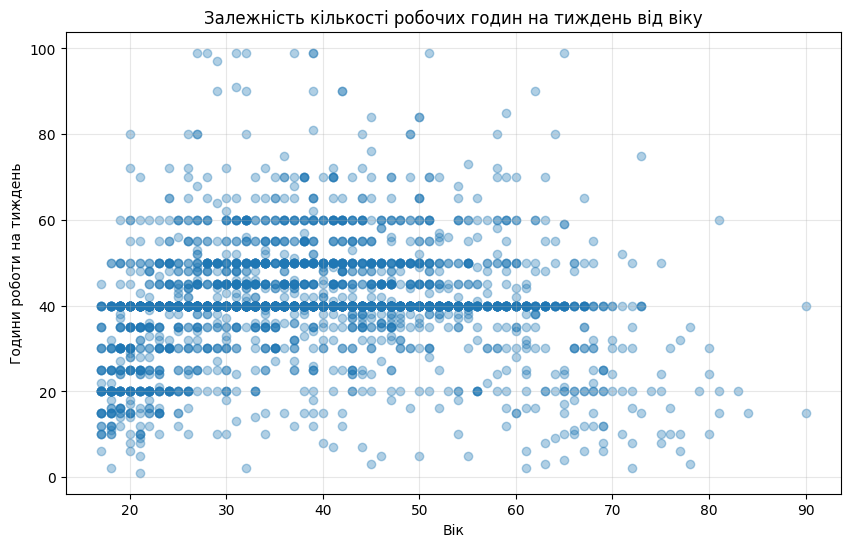

In [8]:
sample_df = clean_df.sample(n=min(3000, len(clean_df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df["age"], sample_df["hours_per_week"], alpha=0.35)
plt.title("Залежність кількості робочих годин на тиждень від віку")
plt.xlabel("Вік")
plt.ylabel("Години роботи на тиждень")
plt.grid(True, alpha=0.3)
plt.show()


## Завдання 5

Побудувати гістограму по одному з атрибутів, яка показує кількість елементів у 5 діапазонах.

Для цього використаємо атрибут `age`.


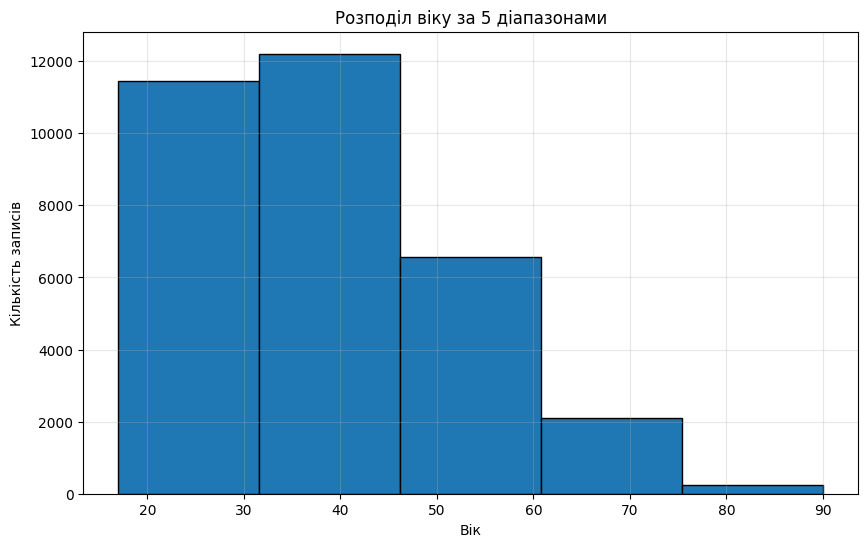

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(clean_df["age"], bins=5, edgecolor="black")
plt.title("Розподіл віку за 5 діапазонами")
plt.xlabel("Вік")
plt.ylabel("Кількість записів")
plt.grid(True, alpha=0.3)
plt.show()


## Завдання 6

Побудувати line plot для аналізу середньої кількості робочих годин залежно від віку.


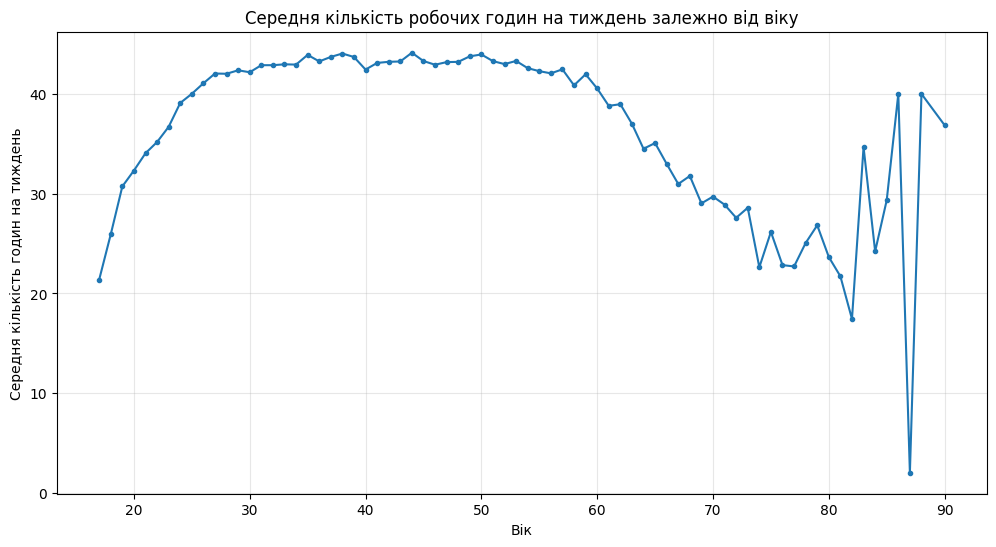

In [10]:
avg_hours_by_age = (
    clean_df.groupby("age", as_index=False)["hours_per_week"]
    .mean()
    .sort_values("age")
)

plt.figure(figsize=(12, 6))
plt.plot(avg_hours_by_age["age"], avg_hours_by_age["hours_per_week"], marker="o", markersize=3)
plt.title("Середня кількість робочих годин на тиждень залежно від віку")
plt.xlabel("Вік")
plt.ylabel("Середня кількість годин на тиждень")
plt.grid(True, alpha=0.3)
plt.show()


## Завдання 7

Побудувати boxplot для порівняння числового атрибута між категоріями.

Порівняємо `education_num` для двох груп доходу.


/tmp/ipykernel_13322/327007885.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(income_groups, labels=["low_income", "high_income"])


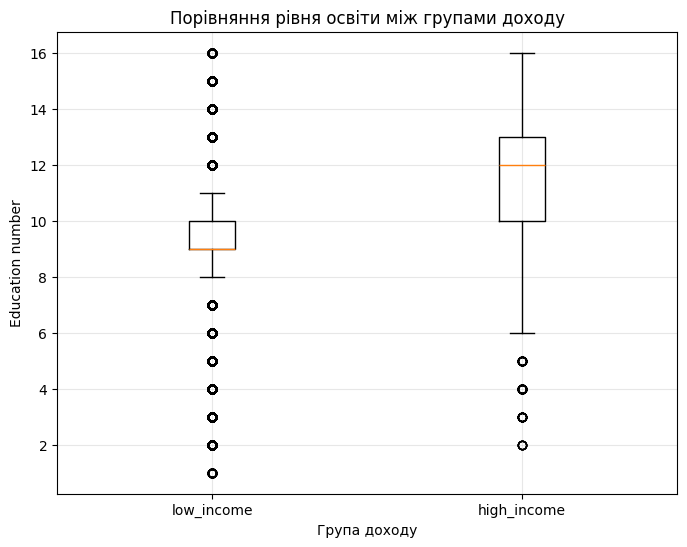

In [11]:
income_groups = [
    clean_df[clean_df["income"] == "low_income"]["education_num"],
    clean_df[clean_df["income"] == "high_income"]["education_num"],
]

plt.figure(figsize=(8, 6))
plt.boxplot(income_groups, labels=["low_income", "high_income"])
plt.title("Порівняння рівня освіти між групами доходу")
plt.xlabel("Група доходу")
plt.ylabel("Education number")
plt.grid(True, alpha=0.3)
plt.show()


## Завдання 8

Побудувати bar chart для категоріального атрибута.

Проаналізуємо кількість записів за рівнем освіти.


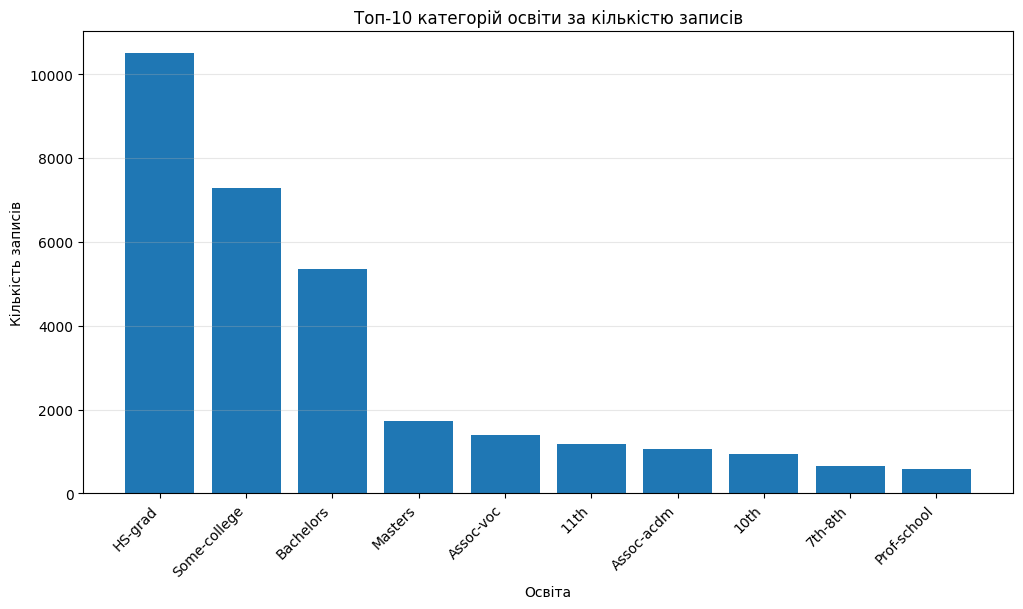

In [12]:
education_counts = clean_df["education"].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(education_counts.index, education_counts.values)
plt.title("Топ-10 категорій освіти за кількістю записів")
plt.xlabel("Освіта")
plt.ylabel("Кількість записів")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Завдання 9

Побудувати графік для багатовимірного аналізу.

Порівняємо середню кількість робочих годин за статтю та групою доходу.


In [13]:
pivot_hours = clean_df.pivot_table(
    values="hours_per_week",
    index="sex",
    columns="income",
    aggfunc="mean"
)

pivot_hours


income,high_income,low_income
sex,,
Female,40.426633,35.921736
Male,46.366817,40.694873


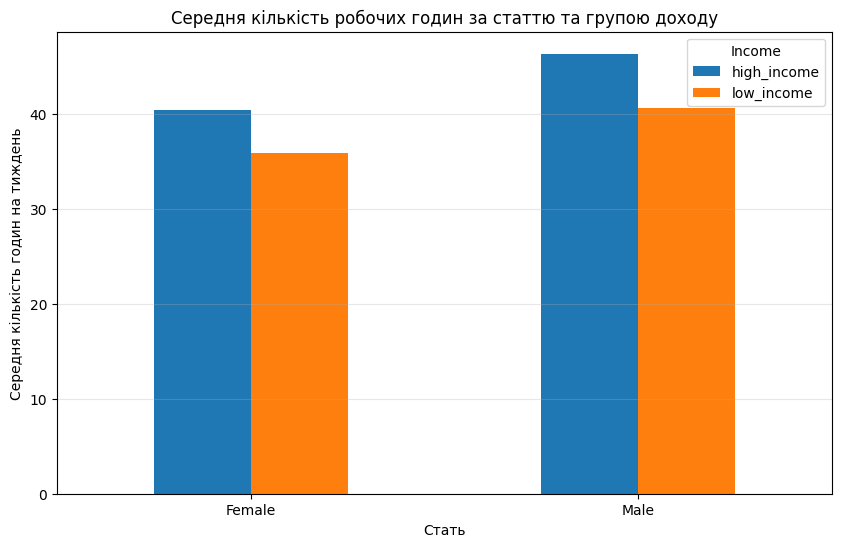

In [14]:
pivot_hours.plot(kind="bar", figsize=(10, 6))
plt.title("Середня кількість робочих годин за статтю та групою доходу")
plt.xlabel("Стать")
plt.ylabel("Середня кількість годин на тиждень")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Income")
plt.show()


## Завдання 10

Побудувати графік кореляцій між числовими атрибутами.


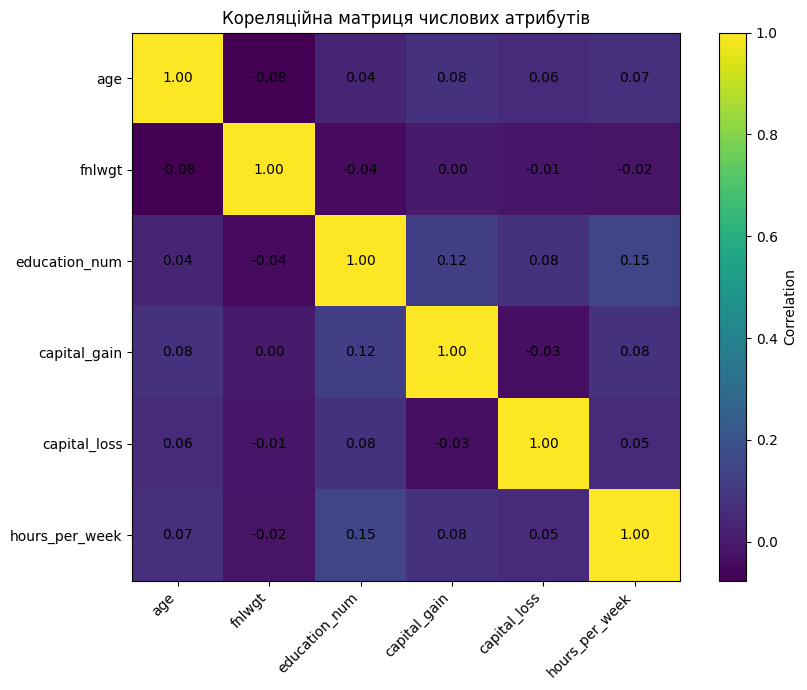

In [15]:
numeric_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
]

corr_matrix = clean_df[numeric_columns].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=45, ha="right")
plt.yticks(range(len(numeric_columns)), numeric_columns)

for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Кореляційна матриця числових атрибутів")
plt.tight_layout()
plt.show()


## Завдання 11

Побудувати stacked bar chart для аналізу частки груп доходу за типом зайнятості.


In [16]:
workclass_income = pd.crosstab(
    clean_df["workclass"],
    clean_df["income"],
    normalize="index"
).sort_values(by="high_income", ascending=False)

workclass_income


income,high_income,low_income
workclass,,
Self-emp-inc,0.557348,0.442652
Federal-gov,0.386458,0.613542
Local-gov,0.294792,0.705208
Self-emp-not-inc,0.285039,0.714961
State-gov,0.271957,0.728043
Private,0.210208,0.789792
Never-worked,0.000000,1.000000
Without-pay,0.000000,1.000000


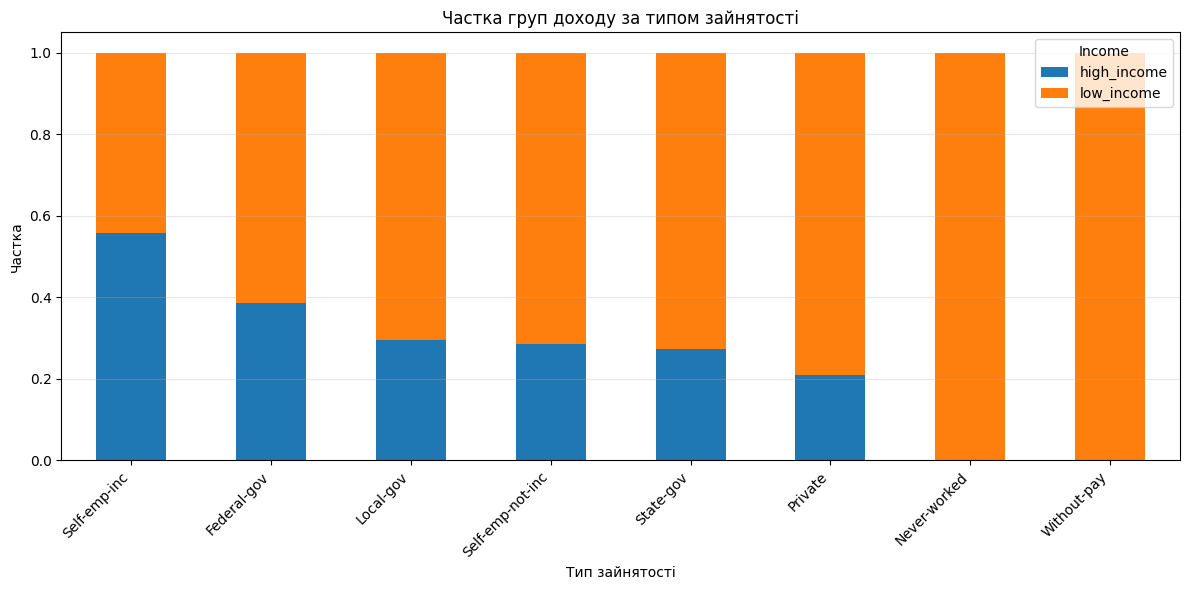

In [17]:
workclass_income.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Частка груп доходу за типом зайнятості")
plt.xlabel("Тип зайнятості")
plt.ylabel("Частка")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Income")
plt.tight_layout()
plt.show()


## Висновки

У лабораторній роботі було:

- обрано багатовимірний датасет із числовими та категоріальними атрибутами;
- виконано очищення даних;
- оброблено пропущені значення;
- побудовано графіки для аналізу числових і категоріальних ознак;
- досліджено взаємозв'язки між віком, освітою, робочими годинами, типом зайнятості та групою доходу.

Загальна кількість побудованих графіків: **7**.
